# MSST Deep Dive

Multi-Synchrosqueezing Transform: from SST to true Pham-Meignen MSST.

Topics:
1. SST vs MSST concentration comparison
2. Iteration effect — how more passes sharpen the TF plane
3. True PM formulation: Tx-derived IF vs W-derived IF
4. Crossing chirps: visual comparison
5. Ridge extraction and reconstruction from MSST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wavesst
from wavesst.viz.tf_plot import _to_numpy
from wavesst.viz.interactive import iplot_sst, iplot_ridges, iplot_components

%matplotlib inline
print(f'wavesst {wavesst.__version__}')

wavesst 0.1.0


In [2]:
FS = 256.0
T  = 2.0
t  = np.arange(int(T * FS)) / FS
cfg = wavesst.Config(device='cpu', dtype='complex64')

f_lin  = 20 + 80 * t / T
f_quad = 120 - 90 * (t / T) ** 2
x = (np.cos(2*np.pi*np.cumsum(f_lin)/FS)
   + np.cos(2*np.pi*np.cumsum(f_quad)/FS)).astype(np.float32)
print(f'Signal: N={len(x)}, fs={FS} Hz')

Signal: N=512, fs=256.0 Hz


## 1 — SST vs MSST: Gini Concentration

Higher Gini = more concentrated = sharper ridges.

In [3]:
def gini(e):
    e = np.sort(np.abs(e))
    n = len(e)
    return (2 * np.sum(np.arange(1, n+1) * e) / (n * e.sum()) - (n+1)/n)

sst_r   = wavesst.sst(x, fs=FS, nv=32, gamma='auto', cfg=cfg)
msst2_r = wavesst.msst(x, fs=FS, nv=32, n_iter=2, gamma='auto', cfg=cfg)
msst3_r = wavesst.msst(x, fs=FS, nv=32, n_iter=3, gamma='auto', cfg=cfg)

for label, r in [('SST (1 iter)', sst_r), ('MSST 2-iter', msst2_r), ('MSST 3-iter', msst3_r)]:
    e = _to_numpy(r.Tx.abs().pow(2).sum(dim=1))
    print(f'{label:20s}  Gini = {gini(e):.4f}')

SST (1 iter)          Gini = 0.5044
MSST 2-iter           Gini = 0.3382
MSST 3-iter           Gini = 0.9786


## 2 — Iteration Effect

Side-by-side TF planes for 1, 2, and 3 squeezing iterations.

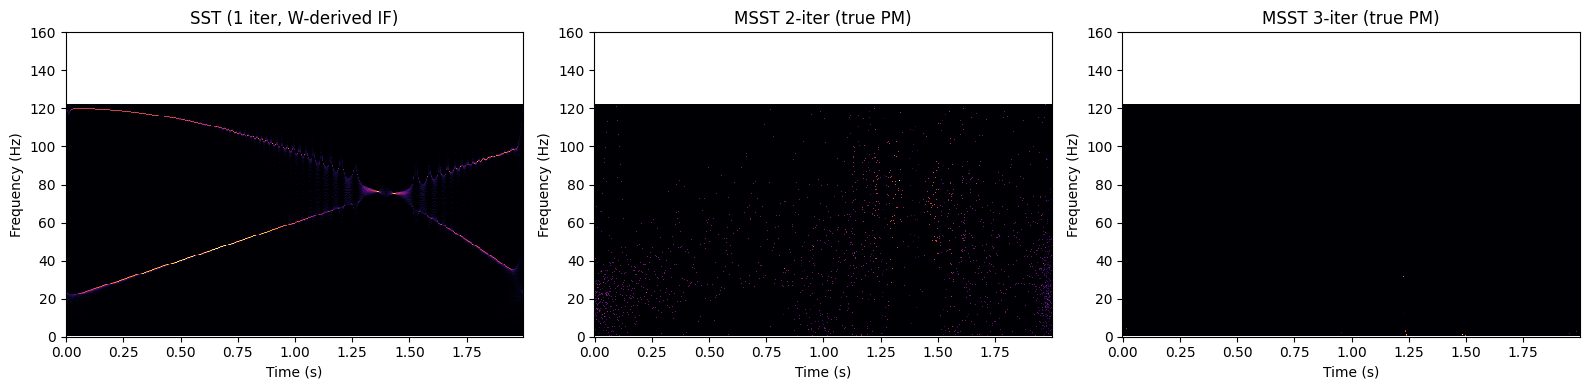

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
datasets = [
    (sst_r,   'SST (1 iter, W-derived IF)'),
    (msst2_r, 'MSST 2-iter (true PM)'),
    (msst3_r, 'MSST 3-iter (true PM)'),
]
for ax, (r, title) in zip(axes, datasets):
    Tx_mag = _to_numpy(r.Tx.abs())
    ax.pcolormesh(_to_numpy(r.times), _to_numpy(r.freqs), Tx_mag,
                  shading='auto', cmap='inferno')
    ax.set_ylim(0, 160)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 3 — True PM vs W-derived IF

The Pham-Meignen (2017) formulation uses the IF estimated from Tx_{k-1}
(not from W) for iterations 2+:

$$\hat{\omega}^k(\xi, t) = \operatorname{Re}\!\left( -i \cdot \frac{\partial_t T_x^{k-1}(\xi,t)}{T_x^{k-1}(\xi,t)} \right)$$

where $\partial_t T_x^{k-1}$ is computed via FFT along the time axis:

$$\partial_t T_x = \operatorname{IFFT}\!\left[ i\omega \cdot \operatorname{FFT}[T_x] \right]$$

`wavesst.msst()` implements this true PM formulation since Session 7.

## 4 — Interactive MSST Explorer

In [5]:
print('--- Interactive SST (baseline) ---')
iplot_sst(sst_r)

--- Interactive SST (baseline) ---


Output()

In [6]:
print('--- Interactive MSST (3 iter, true PM) ---')
iplot_sst(msst3_r)

--- Interactive MSST (3 iter, true PM) ---


Output()

## 5 — Ridge Extraction and Reconstruction from MSST

In [7]:
ridges = wavesst.extract_ridges(msst3_r, n=2, penalty=2.0)
for i, r in enumerate(ridges):
    print(f'Ridge {i+1}: median = {np.median(r.freq_path):.1f} Hz')
iplot_ridges(msst3_r, ridges)

Ridge 1: median = 1.0 Hz
Ridge 2: median = 0.5 Hz


Output()

In [8]:
comps = wavesst.reconstruct(msst3_r, ridges)
iplot_components(comps, msst3_r.times)

Output()